In [20]:
import pydeltasnow as pyds

import os
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"
os.chdir(base_dir)

import HNW_validation.HNW_validation_helper as val_helper

In [21]:
model_source  = "pydeltasnow"

outfile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final_pydsnow_RHO101_MAX539.nc"


In [22]:
if model_source == "pydeltasnow":
    infile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_input_Mag25/Mag25_all.nc" 


    # Load dataset
    Mag25_data = xr.open_dataset(infile)

    # Create copy of original dataset
    Mag25_data_with_SWE = Mag25_data.copy()

    # Add empty SWE_mod variable for all stations
    Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

    # Store number of observed SWE measurements per station
    obs_counts = []

    # Get all station names
    station_list = Mag25_data["station"].values

    for station_name in station_list:
        print(f"\nProcessing station: {station_name}")

        # Select one station and convert to pandas Series
        idata = Mag25_data["HS"].transpose("time", "station").sel(station=station_name).to_pandas()

        print(f"HS input shape: {idata.shape}")

        # Run DeltaSNOW model

        swe_results = pyds.swe_deltasnow(
            idata,
            rho_max   = 539.6471,
            rho_null  = 101.4831,
            c_ov      = 0.00002262494,
            k_ov      = 0.5346488,
            k         = 0.02129925,
            tau       = 0.02489556,
            eta_null  = 8926735,
            hs_input_unit="m",
            swe_output_unit="mm",
            output_series_name="SWE_mod"
        )

        # Check shape
        assert swe_results.shape[0] == Mag25_data.sizes["time"]

        # Insert modeled values for this station
        Mag25_data_with_SWE["SWE_mod"].loc[dict(station=station_name)] = swe_results.values

        # Count available observed SWE measurements
        swe_obs = Mag25_data_with_SWE["SWE"].sel(station=station_name)
        n_obs = swe_obs.notnull().sum().item()
        print(f"Number of SWE observations: {n_obs}")

        obs_counts.append({
            "station": station_name,
            "n_obs": n_obs
        })





elif model_source == "R_deltasnow":


        infile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_input_Mag25/Mag25_all.nc" # always the same 

        csv_file = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_SWE_mod_from_R_dyn_rho_max.csv"


        outfile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final_pydsnow_RHO91_MAX533.nc"

        # load original dataset
        ds = xr.open_dataset(infile)

        # read CSV from R
        SWE_mod = pd.read_csv(csv_file).to_numpy()

        # R matrix is station x time -> xarray needs time x station
        SWE_mod = SWE_mod.T

        # safety check
        assert SWE_mod.shape == (ds.sizes["time"], ds.sizes["station"])

        # add variable
        ds["SWE_mod"] = xr.DataArray(
            SWE_mod,
            coords={"time": ds["time"], "station": ds["station"]},
            dims=("time", "station"),
        )

        ds.to_netcdf(outfile)

        # Load dataset
        Mag25_data = ds

        Mag25_data_with_SWE = Mag25_data.copy()
    


# Create summary table
obs_counts_df = pd.DataFrame(obs_counts)
print(obs_counts_df)

                


Processing station: Adelboden
HS input shape: (2191,)
Number of SWE observations: 32

Processing station: Gadmen
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Grindelwald_Bort
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Gsteig
HS input shape: (2191,)
Number of SWE observations: 52

Processing station: Gantrisch
HS input shape: (2191,)
Number of SWE observations: 53

Processing station: Leysin
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Muerren
HS input shape: (2191,)
Number of SWE observations: 54

Processing station: Saanenmoeser
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Wengen
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Srenberg
HS input shape: (2191,)
Number of SWE observations: 0

Processing station: Stoos
HS input shape: (2191,)
Number of SWE observations: 52

Processing station: Braunwald
HS input shape: (2191,)
Number of SWE 

# Creat HNW_mod Data

In [23]:
# Calculate day-to-day SWE increase
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time")

# Clip negative values to 0
HNW_mod = HNW_mod.clip(min=0)

# Reindex back to the original time axis
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

# Add to dataset
Mag25_data_with_SWE["HNW_mod"] = HNW_mod


Mag25_data_with_SWE.to_netcdf(outfile)

{'RMSE': 2.9561904246838346, 'Bias': 0.07330547555318065, 'Rel_BIAS': 0.034619874532532166, 'R2': 0.8336823584588342, 'N': 36487}


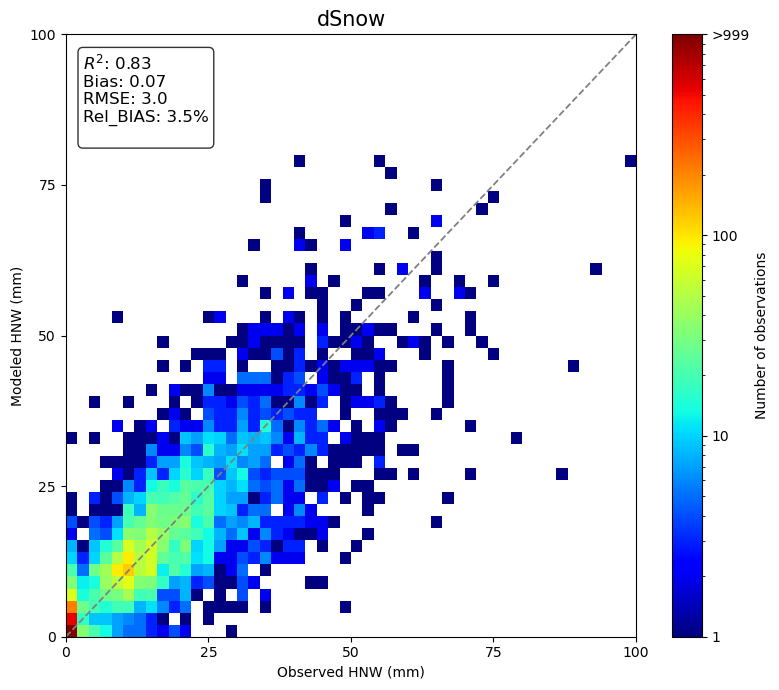

{'RMSE': 2.9561904246838346,
 'Bias': 0.07330547555318065,
 'Rel_BIAS': 0.034619874532532166,
 'R2': 0.8336823584588342,
 'N': 36487}

In [24]:
all_df = Mag25_data_with_SWE[["HNW", "HNW_mod"]].to_dataframe().reset_index()
all_df = all_df.rename(columns={
    "HNW": "HNW_obs",
    "HNW_mod": "HNW_mod"
})

all_df.index = all_df.index.astype("datetime64[ns]")

val_helper.validate_hnw_mag25(all_df,
                            model_name= 'dSnow', 
                            obs_col= "HNW_obs", 
                            mod_col= "HNW_mod"
                            #save_dir="HNW_validation/dSnow/validation_plots",
                            #filename="deltasnow_hnw_validation_R_dyn_rho_max.png"
                            )

In [25]:
# Save output dataset

# Mag25_data_with_SWE.to_netcdf("HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final.nc")
# Mag25_data_with_SWE  = xr.open_dataset('HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final.nc')

# Validate SWE

Number of valid observations after filtering: 1102
{'RMSE': 75.92276232126753, 'Bias': 55.751440979982306, 'Rel_BIAS': 0.24888622766401625, 'R2': 0.777941990440143, 'N': 1102}


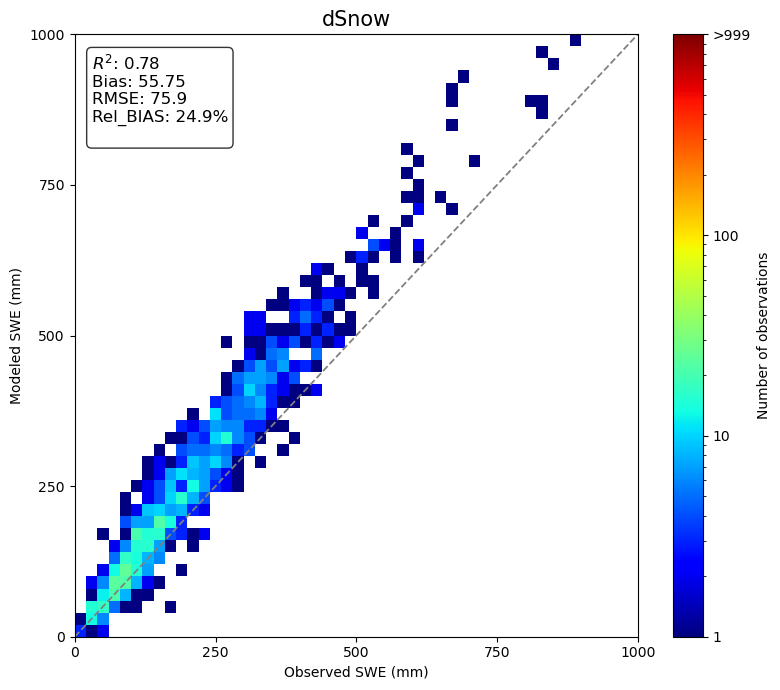

{'RMSE': 75.92276232126753,
 'Bias': 55.751440979982306,
 'Rel_BIAS': 0.24888622766401625,
 'R2': 0.777941990440143,
 'N': 1102}

In [26]:
all_df_SWE = Mag25_data_with_SWE[["SWE", "SWE_mod"]].to_dataframe().reset_index()
all_df_SWE = all_df_SWE.rename(columns={
    "SWE": "SWE_obs",
    "SWE_mod": "SWE_mod"
})

all_df_SWE.index = all_df_SWE.index.astype("datetime64[ns]")

val_helper.validate_swe_mag25(all_df_SWE, 
                              model_name="dSnow"
                              #save_dir="HNW_validation/dSnow/validation_plots",
                              #filename="deltasnow_SWE_validation_R_dyn_rho_max.png"
                              )

In [18]:
import pandas as pd
import numpy as np

orig = np.array([
401.2588,
81.19417,
0.0005104722,
0.37856737,
0.02993175,
0.02362476,
8523356.0
])

opt = np.array([
5.396471e+02,
1.014831e+02,
2.262494e-05,
5.346488e-01,
2.129925e-02,
2.489556e-02,
8.926735e+06
])

names = [
"rho_max","rho_null","c_ov","k_ov","k","tau","eta_null"
]

df = pd.DataFrame({
"parameter":names,
"original":orig,
"optimized":opt,
"diff":opt-orig,
"change_%":100*(opt-orig)/orig
})

print(df)

  parameter      original     optimized           diff   change_%
0   rho_max  4.012588e+02  5.396471e+02     138.388300  34.488540
1  rho_null  8.119417e+01  1.014831e+02      20.288930  24.988161
2      c_ov  5.104722e-04  2.262494e-05      -0.000488 -95.567841
3      k_ov  3.785674e-01  5.346488e-01       0.156081  41.229499
4         k  2.993175e-02  2.129925e-02      -0.008633 -28.840612
5       tau  2.362476e-02  2.489556e-02       0.001271   5.379102
6  eta_null  8.523356e+06  8.926735e+06  403379.000000   4.732631
